### Basisversion Metriken berechnen (neuronales Netz)


In [1]:
import numpy as np
import pandas as pd
import time
import os
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# Augmentierungsfunktionen
# =============================================================================

def perform_clustering(X_sub, max_clusters=4):
    cols = [col for col in X_sub.columns if col not in ["Verletzungsstatus", "Geschlecht_weiblich"]]
    X_num = X_sub[cols]
    # Absolute Korrelationsmatrix, NA-Werte mit 0 auffüllen und Symmetrie erzwingen
    corr = X_num.corr().abs().fillna(0)
    corr = (corr + corr.T) / 2
    dist = np.clip(1 - corr, a_min=0, a_max=None)
    dists = squareform(dist.values)
    Z = linkage(dists, method='ward')
    cluster_labels = fcluster(Z, max_clusters, criterion='maxclust')
    clusters = {}
    for col, label in zip(cols, cluster_labels):
        clusters.setdefault(label, []).append(col)
    return clusters

def augment_subgroup(X_sub, clusters, p_augment=0.7):
    augmented_rows = []
    cluster_params = {}
    for cl_id, cols in clusters.items():
        cluster_data = X_sub[cols]
        mu = cluster_data.mean().values
        if len(cols) == 1:
            cov = np.cov(cluster_data.values.flatten(), ddof=0)
            cov = np.atleast_2d(cov)
        else:
            cov = np.cov(cluster_data.values, rowvar=False)
        cluster_params[cl_id] = (mu, cov, cols)
    for idx, row in X_sub.iterrows():
        new_row = row.copy()
        for cl_id, (mu, cov, cols) in cluster_params.items():
            if np.random.rand() < p_augment:
                new_values = np.random.multivariate_normal(mu, cov)
                for col, val in zip(cols, new_values):
                    new_row[col] = val
        augmented_rows.append(new_row)
    augmented_df = pd.DataFrame(augmented_rows)
    # Binäre Spalten unverändert übernehmen
    for col in ["Geschlecht_weiblich", "Verletzungsstatus"]:
        if col in augmented_df.columns:
            augmented_df[col] = augmented_df[col].astype(int)
    return augmented_df

def process_group_cluster(group_df, num_new_samples, max_clusters, p_augment):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    return pd.concat(aug_list, axis=0)

def augment_training_data_cluster(X_train, y_train, num_new_samples=1, max_clusters=4, p_augment=0.7, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster)(group_df, num_new_samples, max_clusters, p_augment)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def add_noise_to_data(df, noise_factor=0.1):
    df_noisy = df.copy()
    numeric_cols = [col for col in df_noisy.select_dtypes(include=['float64', 'int64']).columns 
                    if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    for col in numeric_cols:
        std = df_noisy[col].std()
        noise = np.random.normal(0, std * noise_factor, size=df_noisy.shape[0])
        df_noisy[col] += noise
    return df_noisy

def add_noise_to_group(df_group, noise_factor=0.1):
    return add_noise_to_data(df_group, noise_factor=noise_factor)

def process_group_cluster_noise(group_df, num_new_samples, max_clusters, p_augment, noise_factor):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    aug_group = pd.concat(aug_list, axis=0).reset_index(drop=True)
    n = len(aug_group)
    half = n // 2
    global_noise = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    group_noise = add_noise_to_group(aug_group.copy(), noise_factor=noise_factor)
    aug_noisy = pd.concat([global_noise.iloc[:half], group_noise.iloc[:half]], axis=0)
    return aug_noisy

def augment_training_data_cluster_noise(X_train, y_train, num_new_samples=1, max_clusters=4, 
                                        p_augment=0.7, noise_factor=0.1, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster_noise)(group_df, num_new_samples, max_clusters, p_augment, noise_factor)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def process_group_means(group_df, group_new_samples):
    """Erzeugt neue Samples durch Mittelwertbildung aus zwei zufällig ausgewählten Samples.
       Dabei werden die binären Spalten 'Verletzungsstatus' und 'Geschlecht_weiblich' direkt übernommen."""
    group_df = group_df.reset_index(drop=True)
    new_group_samples = []
    if len(group_df) < 2:
        return None
    numeric_cols = [col for col in group_df.columns if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    pairs = np.random.choice(len(group_df), (group_new_samples, 2), replace=True)
    for i in range(group_new_samples):
        sample1 = group_df.iloc[pairs[i, 0]]
        sample2 = group_df.iloc[pairs[i, 1]]
        mean_sample = sample1.copy()
        for col in numeric_cols:
            mean_sample[col] = (sample1[col] + sample2[col]) / 2
        mean_sample["Verletzungsstatus"] = sample1["Verletzungsstatus"]
        mean_sample["Geschlecht_weiblich"] = sample1["Geschlecht_weiblich"]
        new_group_samples.append(mean_sample)
    if new_group_samples:
        return pd.DataFrame(new_group_samples)
    return None

def augment_data_by_group_means(X_train, y_train, augmentation_factor=2, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])
    total_original_samples = len(df_train)
    total_new_samples = int(total_original_samples * (augmentation_factor - 1))
    group_sizes = groups.size()
    group_proportions = group_sizes / total_original_samples
    tasks = []
    for (injury_status, is_female), group_df in groups:
        group_new_samples = int(total_new_samples * group_proportions[(injury_status, is_female)])
        tasks.append((group_df, group_new_samples))
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_means)(group_df, group_new_samples)
        for group_df, group_new_samples in tasks
    )
    augmented_groups = [group for group in augmented_groups if group is not None]
    augmented_df = pd.concat([df_train] + augmented_groups, ignore_index=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def augment_training_data_combined(X_train, y_train, target_size=1000, verbose=True, n_jobs=-1,
                                   max_clusters=4, noise_factor=0.1):
    """
    Führt alle drei Augmentierungsmethoden (Cluster-basiert, Cluster+Rauschen, Mittelwert-basiert)
    parallel aus und kombiniert die Ergebnisse, um den Trainingsdatensatz auf die gewünschte Zielgröße zu bringen.
    """
    start_time = time.time()
    N = len(X_train)
    additional_needed = max(target_size - N, 0)
    per_method_needed = additional_needed // 3
    num_new_samples = max(per_method_needed // N, 1)
    augmentation_factor = 1 + (per_method_needed / N)
    if verbose:
        print(f"Starting combined augmentation to reach target size: {target_size}")
        print(f"Original dataset size: {N}")
        print(f"Samples needed per method: {per_method_needed}")
    funcs_and_params = [
        (augment_training_data_cluster, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_training_data_cluster_noise, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_data_by_group_means, {"augmentation_factor": augmentation_factor, "n_jobs": n_jobs})
    ]
    results = Parallel(n_jobs=min(3, n_jobs))(
        delayed(func)(X_train, y_train, **params) for func, params in funcs_and_params
    )
    X_aug_cluster, y_aug_cluster = results[0]
    X_aug_cluster_noise, y_aug_cluster_noise = results[1]
    X_aug_group_means, y_aug_group_means = results[2]
    def subsample(X_aug, y_aug, required):
        if len(X_aug) > required:
            idx = np.random.choice(len(X_aug), required, replace=False)
            return X_aug.iloc[idx].reset_index(drop=True), y_aug.iloc[idx].reset_index(drop=True)
        else:
            return X_aug, y_aug
    X_aug_cluster, y_aug_cluster = subsample(X_aug_cluster, y_aug_cluster, per_method_needed)
    X_aug_cluster_noise, y_aug_cluster_noise = subsample(X_aug_cluster_noise, y_aug_cluster_noise, per_method_needed)
    X_aug_group_means, y_aug_group_means = subsample(X_aug_group_means, y_aug_group_means, per_method_needed)
    X_aug_combined = pd.concat([X_aug_cluster, X_aug_cluster_noise, X_aug_group_means], axis=0).reset_index(drop=True)
    y_aug_combined = pd.concat([y_aug_cluster, y_aug_cluster_noise, y_aug_group_means], axis=0).reset_index(drop=True)
    X_total = pd.concat([X_train.reset_index(drop=True), X_aug_combined], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train.reset_index(drop=True), y_aug_combined], axis=0).reset_index(drop=True)
    if len(X_total) > target_size:
        idx = np.random.choice(len(X_total), target_size, replace=False)
        X_total = X_total.iloc[idx].reset_index(drop=True)
        y_total = y_total.iloc[idx].reset_index(drop=True)
    elapsed_time = time.time() - start_time
    if verbose:
        print(f"Augmentation completed. Final dataset size: {len(X_total)}")
        print(f"Augmentation took {elapsed_time:.2f} seconds")
    return X_total, y_total

# =============================================================================
# Modellaufbau und Training
# =============================================================================

def create_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =============================================================================
# CV-Pipeline
# =============================================================================


def run_cv_pipeline(data_path, target_column="Verletzungsstatus", cv_splits=5, cv_repeats=10,
                    target_augmentation_multiplier=11, verbose=True, n_jobs=-1):
    """
    Liest die Daten ein, führt eine stratified Cross-Validation durch, 
    augmentiert in jedem Fold den Trainingsdatensatz und trainiert anschließend ein Modell.
    Aggregiert die Ergebnisse (Mittelwert und Standardabweichung) und gibt diese zurück.
    """
    try:
        df = pd.read_excel(data_path)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not found in data")
        return None
    y = df[target_column]
    X = df.drop(columns=[target_column])
    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        print(f"Class distribution: {y.value_counts().to_dict()}")
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    metrics_results = []
    for train_index, test_index in cv.split(X, y):
        if verbose:
            print("\n--- New Fold ---")
        X_train, y_train = X.iloc[train_index].copy(), y.iloc[train_index].copy()
        X_test, y_test = X.iloc[test_index].copy(), y.iloc[test_index].copy()
        target_size = int(len(X_train) * target_augmentation_multiplier)
        # Augmentation durchführen
        X_train_aug, y_train_aug = augment_training_data_combined(X_train, y_train,
                                                                   target_size=target_size,
                                                                   verbose=verbose,
                                                                   n_jobs=n_jobs)
        # Skalierung
        scaler = MinMaxScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_aug), columns=X_train.columns)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
        # Modell erstellen und trainieren
        model = create_model(input_dim=X_train_scaled.shape[1])
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        history = model.fit(X_train_scaled, y_train_aug,
                            validation_split=0.2,
                            epochs=100,
                            batch_size=16,
                            callbacks=[early_stop],
                            verbose=0)
        # Evaluation auf Trainingsdaten (Train Accuracy)
        y_train_pred_prob = model.predict(X_train_scaled)
        y_train_pred = (y_train_pred_prob > 0.5).astype(int).flatten()
        train_acc = accuracy_score(y_train_aug, y_train_pred)
        # Evaluation auf Testdaten (Test Accuracy und weitere Metriken)
        y_pred_prob = model.predict(X_test_scaled)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        test_acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        try:
            roc = roc_auc_score(y_test, y_pred_prob)
        except Exception:
            roc = None
        metrics_results.append({
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'f1_score': f1,
            'precision': prec,
            'recall': rec,
            'roc_auc': roc
        })
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics = results_df.std(numeric_only=True)
    aggregated = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}
    return aggregated

def main():
    global aggregated_results
    data_path = r"K:\Team\Böhmer_Michael\TSA\ML\Basistabelle\Feature_Selektion\Basistabelle_ML_Maestroni_Set.xlsx"
    aggregated_results = run_cv_pipeline(data_path, cv_splits=5, cv_repeats=10,
                                         target_augmentation_multiplier=11, verbose=True, n_jobs=-1)
    if aggregated_results is None:
        print("Pipeline failed.")
        return

    print("\n=== Model Performance Summary ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

if __name__ == "__main__":
    main()



Data loaded: 108 samples, 16 features
Class distribution: {1: 56, 0: 52}

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 888
Augmentation took 2.87 seconds
1/1 [==============================] - 0s 17ms/step

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 886
Augmentation took 0.92 seconds
1/1 [==============================] - 0s 15ms/step

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 886
Augmentation took 0.92 seconds
1/1 [==============================] - 0s 15ms/step

--- New Fold ---
Starting combined augmentation to reach target size: 957
Original dataset size: 87
Samples needed per method: 290
Augmen

### Metriken für klinische Anwendbarkeit ergänzen: Brier Score, Calibration Curve und Decision Curve Analysis (DCA)

Data loaded: 108 samples, 47 features
Class distribution: {1: 56, 0: 52}

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 888
Augmentation took 2.96 seconds

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 886
Augmentation took 1.09 seconds

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 886
Augmentation took 1.05 seconds

--- New Fold ---
Starting combined augmentation to reach target size: 957
Original dataset size: 87
Samples needed per method: 290
Augmentation completed. Final dataset size: 896
Augmentation took 1.06 seconds

--- New Fold ---
Starting combined augmentation to reach target size: 957
Original

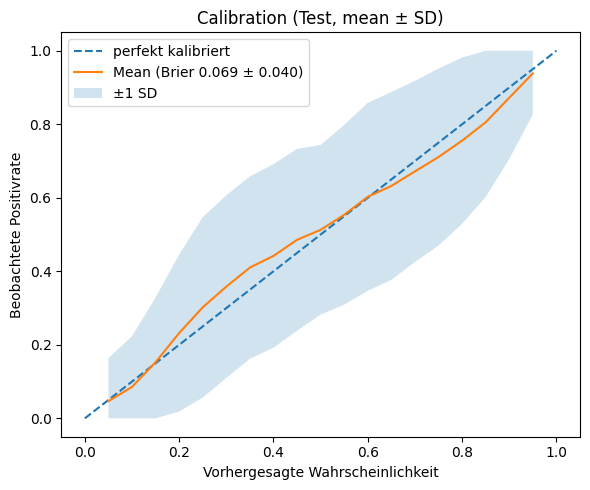

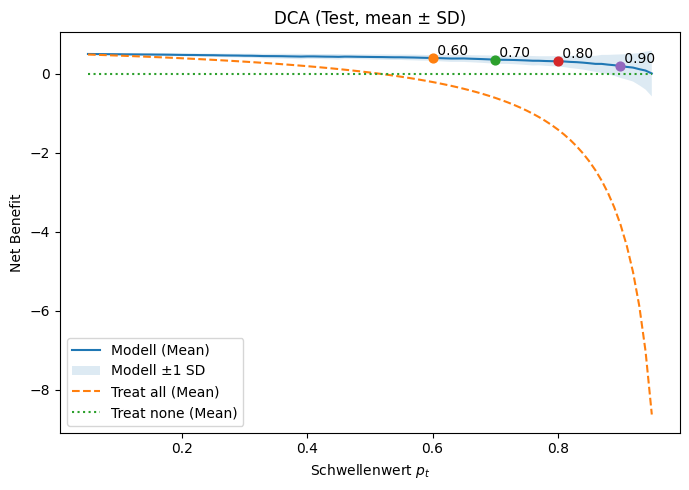

In [2]:
import numpy as np
import pandas as pd
import time
import os
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# --- Einzel-Fold: Calibration (mit Brier) ---
def compute_calibration(y_true, y_prob, n_bins=10):
    """
    Gibt Brier Score + (mean_pred, frac_pos) der Reliability-Kurve zurück.
    strategy='quantile' stabilisiert bei unbalancierten Klassen.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

# --- Einzel-Fold: DCA ---
def decision_curve(y_true, y_prob, thresholds=None):
    """
    Net Benefit nach Vickers & Elkin (2006).
    NB_model = (TP/N) - (FP/N) * (pt/(1-pt))
    NB_treat_all = prevalence - (1-prevalence)*(pt/(1-pt))
    NB_treat_none = 0
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()

    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model = []
    nb_all = []
    nb_none = np.zeros_like(thresholds)

    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb = (TP / N) - (FP / N) * weight
        nb_model.append(nb)

        nb_all_pt = prevalence - (1 - prevalence) * weight
        nb_all.append(nb_all_pt)

    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

# --- Aggregation über Folds: Calibration ---
def aggregate_calibration(cal_list, grid=None):
    """
    Interpoliert jede Fold-Kurve auf ein gemeinsames Gitter der vorhergesagten p.
    Liefert mean±sd der beobachteten Positivrate auf diesem Gitter + gemittelten Brier.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)  # 19 Punkte von 5% bis 95%

    # Interpolation: frac_pos als Funktion von mean_pred
    interp_mat = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"])
        fp = np.asarray(c["frac_pos"])
        # nur valide Bereiche (monoton steigend nicht garantiert, aber ok für Interp)
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        interp_mat.append(interp)

    interp_mat = np.vstack(interp_mat)
    cal_mean = np.nanmean(interp_mat, axis=0)
    cal_std  = np.nanstd(interp_mat, axis=0)
    briers   = np.array([c["brier"] for c in cal_list if "brier" in c])
    brier_mean = float(np.mean(briers)) if len(briers) else np.nan
    brier_std  = float(np.std(briers))  if len(briers) else np.nan

    return {
        "grid": grid,
        "mean_frac_pos": cal_mean,
        "std_frac_pos": cal_std,
        "brier_mean": brier_mean,
        "brier_std": brier_std
    }

# --- Aggregation über Folds: DCA ---
def aggregate_dca(dca_list, grid=None):
    """
    Erzwingt gemeinsames Threshold-Gitter; mittelt NB-Kurven und liefert mean±sd.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)

    nb_model_all = []
    nb_all_all   = []
    nb_none_all  = []

    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m = np.asarray(d["nb_model"])
        nb_a = np.asarray(d["nb_all"])
        nb_n = np.asarray(d["nb_none"])
        nb_model_all.append(np.interp(grid, th, nb_m))
        nb_all_all.append(np.interp(grid, th, nb_a))
        nb_none_all.append(np.interp(grid, th, nb_n))

    nb_model_all = np.vstack(nb_model_all)
    nb_all_all   = np.vstack(nb_all_all)
    nb_none_all  = np.vstack(nb_none_all)

    out = {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_model_all, axis=0),
        "nb_model_std":  np.std(nb_model_all, axis=0),
        "nb_all_mean":   np.mean(nb_all_all, axis=0),
        "nb_all_std":    np.std(nb_all_all, axis=0),
        "nb_none_mean":  np.mean(nb_none_all, axis=0),
        "nb_none_std":   np.std(nb_none_all, axis=0),
    }
    return out

# --- Plots: mittlere Kurven mit SD-Bändern ---
def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]

    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt kalibriert")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit")
    plt.ylabel("Beobachtete Positivrate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]

    plt.figure(figsize=(7,5))
    # Modell
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"] - dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"] + dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")

    # Treat all / none
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")

    if mark_pts is not None:
        for pt in mark_pts:
            if pt >= th.min() and pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40, zorder=5)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')

    plt.xlabel("Schwellenwert $p_t$")
    plt.ylabel("Net Benefit")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# Augmentierungsfunktionen
# =============================================================================

def perform_clustering(X_sub, max_clusters=4):
    cols = [col for col in X_sub.columns if col not in ["Verletzungsstatus", "Geschlecht_weiblich"]]
    X_num = X_sub[cols]
    # Absolute Korrelationsmatrix, NA-Werte mit 0 auffüllen und Symmetrie erzwingen
    corr = X_num.corr().abs().fillna(0)
    corr = (corr + corr.T) / 2
    dist = np.clip(1 - corr, a_min=0, a_max=None)
    dists = squareform(dist.values)
    Z = linkage(dists, method='ward')
    cluster_labels = fcluster(Z, max_clusters, criterion='maxclust')
    clusters = {}
    for col, label in zip(cols, cluster_labels):
        clusters.setdefault(label, []).append(col)
    return clusters

def augment_subgroup(X_sub, clusters, p_augment=0.7):
    augmented_rows = []
    cluster_params = {}
    for cl_id, cols in clusters.items():
        cluster_data = X_sub[cols]
        mu = cluster_data.mean().values
        if len(cols) == 1:
            cov = np.cov(cluster_data.values.flatten(), ddof=0)
            cov = np.atleast_2d(cov)
        else:
            cov = np.cov(cluster_data.values, rowvar=False)
        cluster_params[cl_id] = (mu, cov, cols)
    for idx, row in X_sub.iterrows():
        new_row = row.copy()
        for cl_id, (mu, cov, cols) in cluster_params.items():
            if np.random.rand() < p_augment:
                new_values = np.random.multivariate_normal(mu, cov)
                for col, val in zip(cols, new_values):
                    new_row[col] = val
        augmented_rows.append(new_row)
    augmented_df = pd.DataFrame(augmented_rows)
    # Binäre Spalten unverändert übernehmen
    for col in ["Geschlecht_weiblich", "Verletzungsstatus"]:
        if col in augmented_df.columns:
            augmented_df[col] = augmented_df[col].astype(int)
    return augmented_df

def process_group_cluster(group_df, num_new_samples, max_clusters, p_augment):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    return pd.concat(aug_list, axis=0)

def augment_training_data_cluster(X_train, y_train, num_new_samples=1, max_clusters=4, p_augment=0.7, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster)(group_df, num_new_samples, max_clusters, p_augment)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def add_noise_to_data(df, noise_factor=0.1):
    df_noisy = df.copy()
    numeric_cols = [col for col in df_noisy.select_dtypes(include=['float64', 'int64']).columns 
                    if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    for col in numeric_cols:
        std = df_noisy[col].std()
        noise = np.random.normal(0, std * noise_factor, size=df_noisy.shape[0])
        df_noisy[col] += noise
    return df_noisy

def add_noise_to_group(df_group, noise_factor=0.1):
    return add_noise_to_data(df_group, noise_factor=noise_factor)

def process_group_cluster_noise(group_df, num_new_samples, max_clusters, p_augment, noise_factor):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    aug_group = pd.concat(aug_list, axis=0).reset_index(drop=True)
    n = len(aug_group)
    half = n // 2
    global_noise = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    group_noise = add_noise_to_group(aug_group.copy(), noise_factor=noise_factor)
    aug_noisy = pd.concat([global_noise.iloc[:half], group_noise.iloc[:half]], axis=0)
    return aug_noisy

def augment_training_data_cluster_noise(X_train, y_train, num_new_samples=1, max_clusters=4, 
                                        p_augment=0.7, noise_factor=0.1, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster_noise)(group_df, num_new_samples, max_clusters, p_augment, noise_factor)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def process_group_means(group_df, group_new_samples):
    """Erzeugt neue Samples durch Mittelwertbildung aus zwei zufällig ausgewählten Samples.
       Dabei werden die binären Spalten 'Verletzungsstatus' und 'Geschlecht_weiblich' direkt übernommen."""
    group_df = group_df.reset_index(drop=True)
    new_group_samples = []
    if len(group_df) < 2:
        return None
    numeric_cols = [col for col in group_df.columns if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    pairs = np.random.choice(len(group_df), (group_new_samples, 2), replace=True)
    for i in range(group_new_samples):
        sample1 = group_df.iloc[pairs[i, 0]]
        sample2 = group_df.iloc[pairs[i, 1]]
        mean_sample = sample1.copy()
        for col in numeric_cols:
            mean_sample[col] = (sample1[col] + sample2[col]) / 2
        mean_sample["Verletzungsstatus"] = sample1["Verletzungsstatus"]
        mean_sample["Geschlecht_weiblich"] = sample1["Geschlecht_weiblich"]
        new_group_samples.append(mean_sample)
    if new_group_samples:
        return pd.DataFrame(new_group_samples)
    return None

def augment_data_by_group_means(X_train, y_train, augmentation_factor=2, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])
    total_original_samples = len(df_train)
    total_new_samples = int(total_original_samples * (augmentation_factor - 1))
    group_sizes = groups.size()
    group_proportions = group_sizes / total_original_samples
    tasks = []
    for (injury_status, is_female), group_df in groups:
        group_new_samples = int(total_new_samples * group_proportions[(injury_status, is_female)])
        tasks.append((group_df, group_new_samples))
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_means)(group_df, group_new_samples)
        for group_df, group_new_samples in tasks
    )
    augmented_groups = [group for group in augmented_groups if group is not None]
    augmented_df = pd.concat([df_train] + augmented_groups, ignore_index=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def augment_training_data_combined(X_train, y_train, target_size=1000, verbose=True, n_jobs=-1,
                                   max_clusters=4, noise_factor=0.1):
    """
    Führt alle drei Augmentierungsmethoden (Cluster-basiert, Cluster+Rauschen, Mittelwert-basiert)
    parallel aus und kombiniert die Ergebnisse, um den Trainingsdatensatz auf die gewünschte Zielgröße zu bringen.
    """
    start_time = time.time()
    N = len(X_train)
    additional_needed = max(target_size - N, 0)
    per_method_needed = additional_needed // 3
    num_new_samples = max(per_method_needed // N, 1)
    augmentation_factor = 1 + (per_method_needed / N)
    if verbose:
        print(f"Starting combined augmentation to reach target size: {target_size}")
        print(f"Original dataset size: {N}")
        print(f"Samples needed per method: {per_method_needed}")
    funcs_and_params = [
        (augment_training_data_cluster, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_training_data_cluster_noise, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_data_by_group_means, {"augmentation_factor": augmentation_factor, "n_jobs": n_jobs})
    ]
    results = Parallel(n_jobs=min(3, n_jobs))(
        delayed(func)(X_train, y_train, **params) for func, params in funcs_and_params
    )
    X_aug_cluster, y_aug_cluster = results[0]
    X_aug_cluster_noise, y_aug_cluster_noise = results[1]
    X_aug_group_means, y_aug_group_means = results[2]
    def subsample(X_aug, y_aug, required):
        if len(X_aug) > required:
            idx = np.random.choice(len(X_aug), required, replace=False)
            return X_aug.iloc[idx].reset_index(drop=True), y_aug.iloc[idx].reset_index(drop=True)
        else:
            return X_aug, y_aug
    X_aug_cluster, y_aug_cluster = subsample(X_aug_cluster, y_aug_cluster, per_method_needed)
    X_aug_cluster_noise, y_aug_cluster_noise = subsample(X_aug_cluster_noise, y_aug_cluster_noise, per_method_needed)
    X_aug_group_means, y_aug_group_means = subsample(X_aug_group_means, y_aug_group_means, per_method_needed)
    X_aug_combined = pd.concat([X_aug_cluster, X_aug_cluster_noise, X_aug_group_means], axis=0).reset_index(drop=True)
    y_aug_combined = pd.concat([y_aug_cluster, y_aug_cluster_noise, y_aug_group_means], axis=0).reset_index(drop=True)
    X_total = pd.concat([X_train.reset_index(drop=True), X_aug_combined], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train.reset_index(drop=True), y_aug_combined], axis=0).reset_index(drop=True)
    if len(X_total) > target_size:
        idx = np.random.choice(len(X_total), target_size, replace=False)
        X_total = X_total.iloc[idx].reset_index(drop=True)
        y_total = y_total.iloc[idx].reset_index(drop=True)
    elapsed_time = time.time() - start_time
    if verbose:
        print(f"Augmentation completed. Final dataset size: {len(X_total)}")
        print(f"Augmentation took {elapsed_time:.2f} seconds")
    return X_total, y_total

# =============================================================================
# Modellaufbau und Training
# =============================================================================

def create_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =============================================================================
# CV-Pipeline
# =============================================================================


def run_cv_pipeline(data_path, target_column="Verletzungsstatus", cv_splits=5, cv_repeats=10,
                    target_augmentation_multiplier=11, verbose=True, n_jobs=-1):
    try:
        df = pd.read_excel(data_path)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    if target_column not in df.columns:
        print(f"Target column '{target_column}' not found in data")
        return None

    y = df[target_column]
    X = df.drop(columns=[target_column])

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        print(f"Class distribution: {y.value_counts().to_dict()}")

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)

    metrics_results = []
    cal_list = []    
    dca_list = []    

    for train_index, test_index in cv.split(X, y):
        if verbose:
            print("\n--- New Fold ---")
        X_train, y_train = X.iloc[train_index].copy(), y.iloc[train_index].copy()
        X_test,  y_test  = X.iloc[test_index].copy(),  y.iloc[test_index].copy()

        target_size = int(len(X_train) * target_augmentation_multiplier)
        X_train_aug, y_train_aug = augment_training_data_combined(
            X_train, y_train, target_size=target_size, verbose=verbose, n_jobs=n_jobs
        )

        scaler = MinMaxScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_aug), columns=X_train.columns)
        X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

        model = create_model(input_dim=X_train_scaled.shape[1])
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(X_train_scaled, y_train_aug, validation_split=0.2,
                  epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

        # --- Vorhersagen ---
        y_train_pred_prob = model.predict(X_train_scaled, verbose=0).flatten()
        y_train_pred = (y_train_pred_prob > 0.5).astype(int)
        train_acc = accuracy_score(y_train_aug, y_train_pred)

        y_pred_prob = model.predict(X_test_scaled, verbose=0).flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)
        test_acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        try:
            roc = roc_auc_score(y_test, y_pred_prob)
        except Exception:
            roc = None

        # --- NEW: Calibration + Brier (pro Fold) ---
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        cal_list.append(cal)

        # --- NEW: DCA (pro Fold) ---
        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05, 0.95, 91))
        dca_list.append(dca)

        # --- Brier in metrics_results aufnehmen (Skalar) ---
        metrics_results.append({
            'train_accuracy': train_acc,
            'test_accuracy':  test_acc,
            'f1_score':       f1,
            'precision':      prec,
            'recall':         rec,
            'roc_auc':        roc,
            'brier_score':    cal["brier"]   
        })

    # klassische Tabellen-Metriken:
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    # Aggregierte Kurven:
    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg

def main():
    data_path = r"K:\Team\Böhmer_Michael\TSA\ML\Basistabelle\Feature_Selektion\Basistabelle_ML_20_reduziert.xlsx"
    aggregated_results, cal_agg, dca_agg = run_cv_pipeline(
        data_path, cv_splits=5, cv_repeats=10,
        target_augmentation_multiplier=11, verbose=True, n_jobs=-1
    )
    if aggregated_results is None:
        print("Pipeline failed.")
        return

    print("\n=== Model Performance Summary ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    # Fold-gemittelte Plots:
    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60, 0.70, 0.80, 0.90], title="DCA (Test, mean ± SD)")


if __name__ == "__main__":
    main()



### Metriken reduziertes Set an Metriken

Data loaded: 108 samples, 16 features
Class distribution: {1: 56, 0: 52}

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 888
Augmentation took 2.86 seconds

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 886
Augmentation took 0.93 seconds

--- New Fold ---
Starting combined augmentation to reach target size: 946
Original dataset size: 86
Samples needed per method: 286
Augmentation completed. Final dataset size: 886
Augmentation took 0.91 seconds

--- New Fold ---
Starting combined augmentation to reach target size: 957
Original dataset size: 87
Samples needed per method: 290
Augmentation completed. Final dataset size: 896
Augmentation took 0.93 seconds

--- New Fold ---
Starting combined augmentation to reach target size: 957
Original

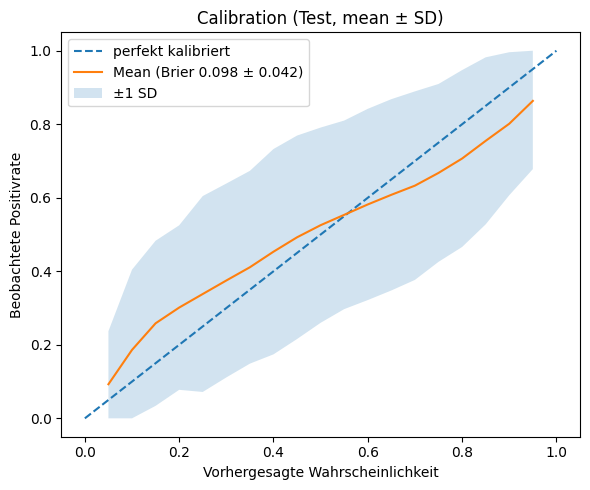

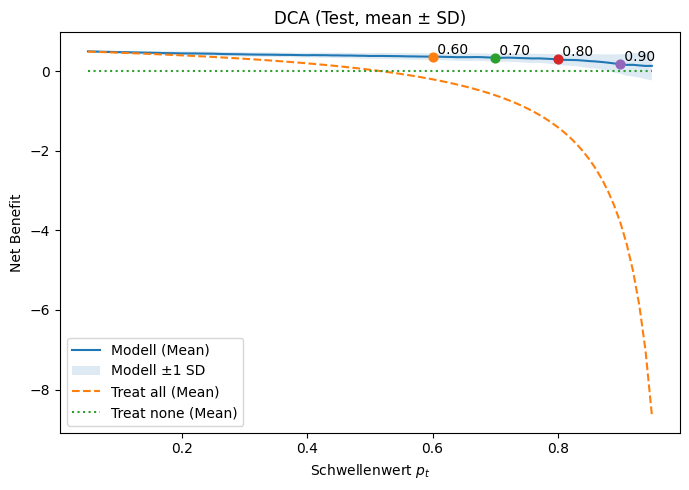

In [3]:
import numpy as np
import pandas as pd
import time
import os
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# --- Einzel-Fold: Calibration (mit Brier) ---
def compute_calibration(y_true, y_prob, n_bins=10):
    """
    Gibt Brier Score + (mean_pred, frac_pos) der Reliability-Kurve zurück.
    strategy='quantile' stabilisiert bei unbalancierten Klassen.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

# --- Einzel-Fold: DCA ---
def decision_curve(y_true, y_prob, thresholds=None):
    """
    Net Benefit nach Vickers & Elkin (2006).
    NB_model = (TP/N) - (FP/N) * (pt/(1-pt))
    NB_treat_all = prevalence - (1-prevalence)*(pt/(1-pt))
    NB_treat_none = 0
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()

    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model = []
    nb_all = []
    nb_none = np.zeros_like(thresholds)

    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb = (TP / N) - (FP / N) * weight
        nb_model.append(nb)

        nb_all_pt = prevalence - (1 - prevalence) * weight
        nb_all.append(nb_all_pt)

    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

# --- Aggregation über Folds: Calibration ---
def aggregate_calibration(cal_list, grid=None):
    """
    Interpoliert jede Fold-Kurve auf ein gemeinsames Gitter der vorhergesagten p.
    Liefert mean±sd der beobachteten Positivrate auf diesem Gitter + gemittelten Brier.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)  # 19 Punkte von 5% bis 95%

    # Interpolation: frac_pos als Funktion von mean_pred
    interp_mat = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"])
        fp = np.asarray(c["frac_pos"])
        # nur valide Bereiche (monoton steigend nicht garantiert, aber ok für Interp)
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        interp_mat.append(interp)

    interp_mat = np.vstack(interp_mat)
    cal_mean = np.nanmean(interp_mat, axis=0)
    cal_std  = np.nanstd(interp_mat, axis=0)
    briers   = np.array([c["brier"] for c in cal_list if "brier" in c])
    brier_mean = float(np.mean(briers)) if len(briers) else np.nan
    brier_std  = float(np.std(briers))  if len(briers) else np.nan

    return {
        "grid": grid,
        "mean_frac_pos": cal_mean,
        "std_frac_pos": cal_std,
        "brier_mean": brier_mean,
        "brier_std": brier_std
    }

# --- Aggregation über Folds: DCA ---
def aggregate_dca(dca_list, grid=None):
    """
    Erzwingt gemeinsames Threshold-Gitter; mittelt NB-Kurven und liefert mean±sd.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)

    nb_model_all = []
    nb_all_all   = []
    nb_none_all  = []

    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m = np.asarray(d["nb_model"])
        nb_a = np.asarray(d["nb_all"])
        nb_n = np.asarray(d["nb_none"])
        nb_model_all.append(np.interp(grid, th, nb_m))
        nb_all_all.append(np.interp(grid, th, nb_a))
        nb_none_all.append(np.interp(grid, th, nb_n))

    nb_model_all = np.vstack(nb_model_all)
    nb_all_all   = np.vstack(nb_all_all)
    nb_none_all  = np.vstack(nb_none_all)

    out = {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_model_all, axis=0),
        "nb_model_std":  np.std(nb_model_all, axis=0),
        "nb_all_mean":   np.mean(nb_all_all, axis=0),
        "nb_all_std":    np.std(nb_all_all, axis=0),
        "nb_none_mean":  np.mean(nb_none_all, axis=0),
        "nb_none_std":   np.std(nb_none_all, axis=0),
    }
    return out

# --- Plots: mittlere Kurven mit SD-Bändern ---
def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]

    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt kalibriert")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit")
    plt.ylabel("Beobachtete Positivrate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]

    plt.figure(figsize=(7,5))
    # Modell
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"] - dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"] + dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")

    # Treat all / none
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")

    if mark_pts is not None:
        for pt in mark_pts:
            if pt >= th.min() and pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40, zorder=5)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')

    plt.xlabel("Schwellenwert $p_t$")
    plt.ylabel("Net Benefit")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# Augmentierungsfunktionen
# =============================================================================

def perform_clustering(X_sub, max_clusters=4):
    cols = [col for col in X_sub.columns if col not in ["Verletzungsstatus", "Geschlecht_weiblich"]]
    X_num = X_sub[cols]
    # Absolute Korrelationsmatrix, NA-Werte mit 0 auffüllen und Symmetrie erzwingen
    corr = X_num.corr().abs().fillna(0)
    corr = (corr + corr.T) / 2
    dist = np.clip(1 - corr, a_min=0, a_max=None)
    dists = squareform(dist.values)
    Z = linkage(dists, method='ward')
    cluster_labels = fcluster(Z, max_clusters, criterion='maxclust')
    clusters = {}
    for col, label in zip(cols, cluster_labels):
        clusters.setdefault(label, []).append(col)
    return clusters

def augment_subgroup(X_sub, clusters, p_augment=0.7):
    augmented_rows = []
    cluster_params = {}
    for cl_id, cols in clusters.items():
        cluster_data = X_sub[cols]
        mu = cluster_data.mean().values
        if len(cols) == 1:
            cov = np.cov(cluster_data.values.flatten(), ddof=0)
            cov = np.atleast_2d(cov)
        else:
            cov = np.cov(cluster_data.values, rowvar=False)
        cluster_params[cl_id] = (mu, cov, cols)
    for idx, row in X_sub.iterrows():
        new_row = row.copy()
        for cl_id, (mu, cov, cols) in cluster_params.items():
            if np.random.rand() < p_augment:
                new_values = np.random.multivariate_normal(mu, cov)
                for col, val in zip(cols, new_values):
                    new_row[col] = val
        augmented_rows.append(new_row)
    augmented_df = pd.DataFrame(augmented_rows)
    # Binäre Spalten unverändert übernehmen
    for col in ["Geschlecht_weiblich", "Verletzungsstatus"]:
        if col in augmented_df.columns:
            augmented_df[col] = augmented_df[col].astype(int)
    return augmented_df

def process_group_cluster(group_df, num_new_samples, max_clusters, p_augment):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    return pd.concat(aug_list, axis=0)

def augment_training_data_cluster(X_train, y_train, num_new_samples=1, max_clusters=4, p_augment=0.7, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster)(group_df, num_new_samples, max_clusters, p_augment)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def add_noise_to_data(df, noise_factor=0.1):
    df_noisy = df.copy()
    numeric_cols = [col for col in df_noisy.select_dtypes(include=['float64', 'int64']).columns 
                    if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    for col in numeric_cols:
        std = df_noisy[col].std()
        noise = np.random.normal(0, std * noise_factor, size=df_noisy.shape[0])
        df_noisy[col] += noise
    return df_noisy

def add_noise_to_group(df_group, noise_factor=0.1):
    return add_noise_to_data(df_group, noise_factor=noise_factor)

def process_group_cluster_noise(group_df, num_new_samples, max_clusters, p_augment, noise_factor):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    aug_group = pd.concat(aug_list, axis=0).reset_index(drop=True)
    n = len(aug_group)
    half = n // 2
    global_noise = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    group_noise = add_noise_to_group(aug_group.copy(), noise_factor=noise_factor)
    aug_noisy = pd.concat([global_noise.iloc[:half], group_noise.iloc[:half]], axis=0)
    return aug_noisy

def augment_training_data_cluster_noise(X_train, y_train, num_new_samples=1, max_clusters=4, 
                                        p_augment=0.7, noise_factor=0.1, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster_noise)(group_df, num_new_samples, max_clusters, p_augment, noise_factor)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def process_group_means(group_df, group_new_samples):
    """Erzeugt neue Samples durch Mittelwertbildung aus zwei zufällig ausgewählten Samples.
       Dabei werden die binären Spalten 'Verletzungsstatus' und 'Geschlecht_weiblich' direkt übernommen."""
    group_df = group_df.reset_index(drop=True)
    new_group_samples = []
    if len(group_df) < 2:
        return None
    numeric_cols = [col for col in group_df.columns if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    pairs = np.random.choice(len(group_df), (group_new_samples, 2), replace=True)
    for i in range(group_new_samples):
        sample1 = group_df.iloc[pairs[i, 0]]
        sample2 = group_df.iloc[pairs[i, 1]]
        mean_sample = sample1.copy()
        for col in numeric_cols:
            mean_sample[col] = (sample1[col] + sample2[col]) / 2
        mean_sample["Verletzungsstatus"] = sample1["Verletzungsstatus"]
        mean_sample["Geschlecht_weiblich"] = sample1["Geschlecht_weiblich"]
        new_group_samples.append(mean_sample)
    if new_group_samples:
        return pd.DataFrame(new_group_samples)
    return None

def augment_data_by_group_means(X_train, y_train, augmentation_factor=2, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])
    total_original_samples = len(df_train)
    total_new_samples = int(total_original_samples * (augmentation_factor - 1))
    group_sizes = groups.size()
    group_proportions = group_sizes / total_original_samples
    tasks = []
    for (injury_status, is_female), group_df in groups:
        group_new_samples = int(total_new_samples * group_proportions[(injury_status, is_female)])
        tasks.append((group_df, group_new_samples))
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_means)(group_df, group_new_samples)
        for group_df, group_new_samples in tasks
    )
    augmented_groups = [group for group in augmented_groups if group is not None]
    augmented_df = pd.concat([df_train] + augmented_groups, ignore_index=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def augment_training_data_combined(X_train, y_train, target_size=1000, verbose=True, n_jobs=-1,
                                   max_clusters=4, noise_factor=0.1):
    """
    Führt alle drei Augmentierungsmethoden (Cluster-basiert, Cluster+Rauschen, Mittelwert-basiert)
    parallel aus und kombiniert die Ergebnisse, um den Trainingsdatensatz auf die gewünschte Zielgröße zu bringen.
    """
    start_time = time.time()
    N = len(X_train)
    additional_needed = max(target_size - N, 0)
    per_method_needed = additional_needed // 3
    num_new_samples = max(per_method_needed // N, 1)
    augmentation_factor = 1 + (per_method_needed / N)
    if verbose:
        print(f"Starting combined augmentation to reach target size: {target_size}")
        print(f"Original dataset size: {N}")
        print(f"Samples needed per method: {per_method_needed}")
    funcs_and_params = [
        (augment_training_data_cluster, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_training_data_cluster_noise, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_data_by_group_means, {"augmentation_factor": augmentation_factor, "n_jobs": n_jobs})
    ]
    results = Parallel(n_jobs=min(3, n_jobs))(
        delayed(func)(X_train, y_train, **params) for func, params in funcs_and_params
    )
    X_aug_cluster, y_aug_cluster = results[0]
    X_aug_cluster_noise, y_aug_cluster_noise = results[1]
    X_aug_group_means, y_aug_group_means = results[2]
    def subsample(X_aug, y_aug, required):
        if len(X_aug) > required:
            idx = np.random.choice(len(X_aug), required, replace=False)
            return X_aug.iloc[idx].reset_index(drop=True), y_aug.iloc[idx].reset_index(drop=True)
        else:
            return X_aug, y_aug
    X_aug_cluster, y_aug_cluster = subsample(X_aug_cluster, y_aug_cluster, per_method_needed)
    X_aug_cluster_noise, y_aug_cluster_noise = subsample(X_aug_cluster_noise, y_aug_cluster_noise, per_method_needed)
    X_aug_group_means, y_aug_group_means = subsample(X_aug_group_means, y_aug_group_means, per_method_needed)
    X_aug_combined = pd.concat([X_aug_cluster, X_aug_cluster_noise, X_aug_group_means], axis=0).reset_index(drop=True)
    y_aug_combined = pd.concat([y_aug_cluster, y_aug_cluster_noise, y_aug_group_means], axis=0).reset_index(drop=True)
    X_total = pd.concat([X_train.reset_index(drop=True), X_aug_combined], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train.reset_index(drop=True), y_aug_combined], axis=0).reset_index(drop=True)
    if len(X_total) > target_size:
        idx = np.random.choice(len(X_total), target_size, replace=False)
        X_total = X_total.iloc[idx].reset_index(drop=True)
        y_total = y_total.iloc[idx].reset_index(drop=True)
    elapsed_time = time.time() - start_time
    if verbose:
        print(f"Augmentation completed. Final dataset size: {len(X_total)}")
        print(f"Augmentation took {elapsed_time:.2f} seconds")
    return X_total, y_total

# =============================================================================
# Modellaufbau und Training
# =============================================================================

def create_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =============================================================================
# CV-Pipeline
# =============================================================================


def run_cv_pipeline(data_path, target_column="Verletzungsstatus", cv_splits=5, cv_repeats=10,
                    target_augmentation_multiplier=11, verbose=True, n_jobs=-1):
    try:
        df = pd.read_excel(data_path)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    if target_column not in df.columns:
        print(f"Target column '{target_column}' not found in data")
        return None

    y = df[target_column]
    X = df.drop(columns=[target_column])

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        print(f"Class distribution: {y.value_counts().to_dict()}")

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)

    metrics_results = []
    cal_list = []    
    dca_list = []    

    for train_index, test_index in cv.split(X, y):
        if verbose:
            print("\n--- New Fold ---")
        X_train, y_train = X.iloc[train_index].copy(), y.iloc[train_index].copy()
        X_test,  y_test  = X.iloc[test_index].copy(),  y.iloc[test_index].copy()

        target_size = int(len(X_train) * target_augmentation_multiplier)
        X_train_aug, y_train_aug = augment_training_data_combined(
            X_train, y_train, target_size=target_size, verbose=verbose, n_jobs=n_jobs
        )

        scaler = MinMaxScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_aug), columns=X_train.columns)
        X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

        model = create_model(input_dim=X_train_scaled.shape[1])
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(X_train_scaled, y_train_aug, validation_split=0.2,
                  epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

        # --- Vorhersagen ---
        y_train_pred_prob = model.predict(X_train_scaled, verbose=0).flatten()
        y_train_pred = (y_train_pred_prob > 0.5).astype(int)
        train_acc = accuracy_score(y_train_aug, y_train_pred)

        y_pred_prob = model.predict(X_test_scaled, verbose=0).flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)
        test_acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        try:
            roc = roc_auc_score(y_test, y_pred_prob)
        except Exception:
            roc = None

        # --- NEW: Calibration + Brier (pro Fold) ---
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        cal_list.append(cal)

        # --- NEW: DCA (pro Fold) ---
        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05, 0.95, 91))
        dca_list.append(dca)

        # --- Brier in metrics_results aufnehmen (Skalar) ---
        metrics_results.append({
            'train_accuracy': train_acc,
            'test_accuracy':  test_acc,
            'f1_score':       f1,
            'precision':      prec,
            'recall':         rec,
            'roc_auc':        roc,
            'brier_score':    cal["brier"]   
        })

    # klassische Tabellen-Metriken:
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    # Aggregierte Kurven:
    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg

def main():
    data_path = r"K:\Team\Böhmer_Michael\TSA\ML\Basistabelle\Feature_Selektion\Basistabelle_ML_Maestroni_Set.xlsx"
    aggregated_results, cal_agg, dca_agg = run_cv_pipeline(
        data_path, cv_splits=5, cv_repeats=10,
        target_augmentation_multiplier=11, verbose=True, n_jobs=-1
    )
    if aggregated_results is None:
        print("Pipeline failed.")
        return

    print("\n=== Model Performance Summary ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    # Fold-gemittelte Plots:
    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60, 0.70, 0.80, 0.90], title="DCA (Test, mean ± SD)")


if __name__ == "__main__":
    main()


### Externe Validierung

In [ ]:
import numpy as np
import pandas as pd
import time
import os
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# =============================================================================
# Kalibration und DCA
# =============================================================================

# --- Einzel-Fold: Calibration (mit Brier) ---
def compute_calibration(y_true, y_prob, n_bins=10):
    """
    Gibt Brier Score + (mean_pred, frac_pos) der Reliability-Kurve zurück.
    strategy='quantile' stabilisiert bei unbalancierten Klassen.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

# --- Einzel-Fold: DCA ---
def decision_curve(y_true, y_prob, thresholds=None):
    """
    Net Benefit nach Vickers & Elkin (2006).
    NB_model = (TP/N) - (FP/N) * (pt/(1-pt))
    NB_treat_all = prevalence - (1-prevalence)*(pt/(1-pt))
    NB_treat_none = 0
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()

    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model = []
    nb_all = []
    nb_none = np.zeros_like(thresholds)

    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb = (TP / N) - (FP / N) * weight
        nb_model.append(nb)

        nb_all_pt = prevalence - (1 - prevalence) * weight
        nb_all.append(nb_all_pt)

    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

# --- Aggregation über Folds: Calibration ---
def aggregate_calibration(cal_list, grid=None):
    """
    Interpoliert jede Fold-Kurve auf ein gemeinsames Gitter der vorhergesagten p.
    Liefert mean±sd der beobachteten Positivrate auf diesem Gitter + gemittelten Brier.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)  # 19 Punkte von 5% bis 95%

    # Interpolation: frac_pos als Funktion von mean_pred
    interp_mat = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"])
        fp = np.asarray(c["frac_pos"])
        # nur valide Bereiche (monoton steigend nicht garantiert, aber ok für Interp)
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        interp_mat.append(interp)

    interp_mat = np.vstack(interp_mat)
    cal_mean = np.nanmean(interp_mat, axis=0)
    cal_std  = np.nanstd(interp_mat, axis=0)
    briers   = np.array([c["brier"] for c in cal_list if "brier" in c])
    brier_mean = float(np.mean(briers)) if len(briers) else np.nan
    brier_std  = float(np.std(briers))  if len(briers) else np.nan

    return {
        "grid": grid,
        "mean_frac_pos": cal_mean,
        "std_frac_pos": cal_std,
        "brier_mean": brier_mean,
        "brier_std": brier_std
    }

# --- Aggregation über Folds: DCA ---
def aggregate_dca(dca_list, grid=None):
    """
    Erzwingt gemeinsames Threshold-Gitter; mittelt NB-Kurven und liefert mean±sd.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)

    nb_model_all = []
    nb_all_all   = []
    nb_none_all  = []

    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m = np.asarray(d["nb_model"])
        nb_a = np.asarray(d["nb_all"])
        nb_n = np.asarray(d["nb_none"])
        nb_model_all.append(np.interp(grid, th, nb_m))
        nb_all_all.append(np.interp(grid, th, nb_a))
        nb_none_all.append(np.interp(grid, th, nb_n))

    nb_model_all = np.vstack(nb_model_all)
    nb_all_all   = np.vstack(nb_all_all)
    nb_none_all  = np.vstack(nb_none_all)

    out = {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_model_all, axis=0),
        "nb_model_std":  np.std(nb_model_all, axis=0),
        "nb_all_mean":   np.mean(nb_all_all, axis=0),
        "nb_all_std":    np.std(nb_all_all, axis=0),
        "nb_none_mean":  np.mean(nb_none_all, axis=0),
        "nb_none_std":   np.std(nb_none_all, axis=0),
    }
    return out

# --- Plots: mittlere Kurven mit SD-Bändern ---
def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]

    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt kalibriert")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit")
    plt.ylabel("Beobachtete Positivrate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]

    plt.figure(figsize=(7,5))
    # Modell
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"] - dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"] + dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")

    # Treat all / none
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")

    if mark_pts is not None:
        for pt in mark_pts:
            if pt >= th.min() and pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40, zorder=5)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')

    plt.xlabel("Schwellenwert $p_t$")
    plt.ylabel("Net Benefit")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# Augmentierungsfunktionen
# =============================================================================

def perform_clustering(X_sub, max_clusters=4):
    cols = [col for col in X_sub.columns if col not in ["Verletzungsstatus", "Geschlecht_weiblich"]]
    X_num = X_sub[cols]
    # Absolute Korrelationsmatrix, NA-Werte mit 0 auffüllen und Symmetrie erzwingen
    corr = X_num.corr().abs().fillna(0)
    corr = (corr + corr.T) / 2
    dist = np.clip(1 - corr, a_min=0, a_max=None)
    dists = squareform(dist.values)
    Z = linkage(dists, method='ward')
    cluster_labels = fcluster(Z, max_clusters, criterion='maxclust')
    clusters = {}
    for col, label in zip(cols, cluster_labels):
        clusters.setdefault(label, []).append(col)
    return clusters

def augment_subgroup(X_sub, clusters, p_augment=0.7):
    augmented_rows = []
    cluster_params = {}
    for cl_id, cols in clusters.items():
        cluster_data = X_sub[cols]
        mu = cluster_data.mean().values
        if len(cols) == 1:
            cov = np.cov(cluster_data.values.flatten(), ddof=0)
            cov = np.atleast_2d(cov)
        else:
            cov = np.cov(cluster_data.values, rowvar=False)
        cluster_params[cl_id] = (mu, cov, cols)
    for idx, row in X_sub.iterrows():
        new_row = row.copy()
        for cl_id, (mu, cov, cols) in cluster_params.items():
            if np.random.rand() < p_augment:
                new_values = np.random.multivariate_normal(mu, cov)
                for col, val in zip(cols, new_values):
                    new_row[col] = val
        augmented_rows.append(new_row)
    augmented_df = pd.DataFrame(augmented_rows)
    # Binäre Spalten unverändert übernehmen
    for col in ["Geschlecht_weiblich", "Verletzungsstatus"]:
        if col in augmented_df.columns:
            augmented_df[col] = augmented_df[col].astype(int)
    return augmented_df

def process_group_cluster(group_df, num_new_samples, max_clusters, p_augment):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    return pd.concat(aug_list, axis=0)

def augment_training_data_cluster(X_train, y_train, num_new_samples=1, max_clusters=4, p_augment=0.7, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster)(group_df, num_new_samples, max_clusters, p_augment)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def add_noise_to_data(df, noise_factor=0.1):
    df_noisy = df.copy()
    numeric_cols = [col for col in df_noisy.select_dtypes(include=['float64', 'int64']).columns 
                    if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    for col in numeric_cols:
        std = df_noisy[col].std()
        noise = np.random.normal(0, std * noise_factor, size=df_noisy.shape[0])
        df_noisy[col] += noise
    return df_noisy

def add_noise_to_group(df_group, noise_factor=0.1):
    return add_noise_to_data(df_group, noise_factor=noise_factor)

def process_group_cluster_noise(group_df, num_new_samples, max_clusters, p_augment, noise_factor):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    aug_group = pd.concat(aug_list, axis=0).reset_index(drop=True)
    n = len(aug_group)
    half = n // 2
    global_noise = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    group_noise = add_noise_to_group(aug_group.copy(), noise_factor=noise_factor)
    aug_noisy = pd.concat([global_noise.iloc[:half], group_noise.iloc[:half]], axis=0)
    return aug_noisy

def augment_training_data_cluster_noise(X_train, y_train, num_new_samples=1, max_clusters=4, 
                                        p_augment=0.7, noise_factor=0.1, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster_noise)(group_df, num_new_samples, max_clusters, p_augment, noise_factor)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def process_group_means(group_df, group_new_samples):
    """Erzeugt neue Samples durch Mittelwertbildung aus zwei zufällig ausgewählten Samples.
       Dabei werden die binären Spalten 'Verletzungsstatus' und 'Geschlecht_weiblich' direkt übernommen."""
    group_df = group_df.reset_index(drop=True)
    new_group_samples = []
    if len(group_df) < 2:
        return None
    numeric_cols = [col for col in group_df.columns if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    pairs = np.random.choice(len(group_df), (group_new_samples, 2), replace=True)
    for i in range(group_new_samples):
        sample1 = group_df.iloc[pairs[i, 0]]
        sample2 = group_df.iloc[pairs[i, 1]]
        mean_sample = sample1.copy()
        for col in numeric_cols:
            mean_sample[col] = (sample1[col] + sample2[col]) / 2
        mean_sample["Verletzungsstatus"] = sample1["Verletzungsstatus"]
        mean_sample["Geschlecht_weiblich"] = sample1["Geschlecht_weiblich"]
        new_group_samples.append(mean_sample)
    if new_group_samples:
        return pd.DataFrame(new_group_samples)
    return None

def augment_data_by_group_means(X_train, y_train, augmentation_factor=2, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])
    total_original_samples = len(df_train)
    total_new_samples = int(total_original_samples * (augmentation_factor - 1))
    group_sizes = groups.size()
    group_proportions = group_sizes / total_original_samples
    tasks = []
    for (injury_status, is_female), group_df in groups:
        group_new_samples = int(total_new_samples * group_proportions[(injury_status, is_female)])
        tasks.append((group_df, group_new_samples))
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_means)(group_df, group_new_samples)
        for group_df, group_new_samples in tasks
    )
    augmented_groups = [group for group in augmented_groups if group is not None]
    augmented_df = pd.concat([df_train] + augmented_groups, ignore_index=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def augment_training_data_combined(X_train, y_train, target_size=1000, verbose=True, n_jobs=-1,
                                   max_clusters=4, noise_factor=0.1):
    """
    Führt alle drei Augmentierungsmethoden (Cluster-basiert, Cluster+Rauschen, Mittelwert-basiert)
    parallel aus und kombiniert die Ergebnisse, um den Trainingsdatensatz auf die gewünschte Zielgröße zu bringen.
    """
    start_time = time.time()
    N = len(X_train)
    additional_needed = max(target_size - N, 0)
    per_method_needed = additional_needed // 3
    num_new_samples = max(per_method_needed // N, 1)
    augmentation_factor = 1 + (per_method_needed / N)
    if verbose:
        print(f"Starting combined augmentation to reach target size: {target_size}")
        print(f"Original dataset size: {N}")
        print(f"Samples needed per method: {per_method_needed}")
    funcs_and_params = [
        (augment_training_data_cluster, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_training_data_cluster_noise, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_data_by_group_means, {"augmentation_factor": augmentation_factor, "n_jobs": n_jobs})
    ]
    results = Parallel(n_jobs=min(3, n_jobs))(
        delayed(func)(X_train, y_train, **params) for func, params in funcs_and_params
    )
    X_aug_cluster, y_aug_cluster = results[0]
    X_aug_cluster_noise, y_aug_cluster_noise = results[1]
    X_aug_group_means, y_aug_group_means = results[2]
    def subsample(X_aug, y_aug, required):
        if len(X_aug) > required:
            idx = np.random.choice(len(X_aug), required, replace=False)
            return X_aug.iloc[idx].reset_index(drop=True), y_aug.iloc[idx].reset_index(drop=True)
        else:
            return X_aug, y_aug
    X_aug_cluster, y_aug_cluster = subsample(X_aug_cluster, y_aug_cluster, per_method_needed)
    X_aug_cluster_noise, y_aug_cluster_noise = subsample(X_aug_cluster_noise, y_aug_cluster_noise, per_method_needed)
    X_aug_group_means, y_aug_group_means = subsample(X_aug_group_means, y_aug_group_means, per_method_needed)
    X_aug_combined = pd.concat([X_aug_cluster, X_aug_cluster_noise, X_aug_group_means], axis=0).reset_index(drop=True)
    y_aug_combined = pd.concat([y_aug_cluster, y_aug_cluster_noise, y_aug_group_means], axis=0).reset_index(drop=True)
    X_total = pd.concat([X_train.reset_index(drop=True), X_aug_combined], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train.reset_index(drop=True), y_aug_combined], axis=0).reset_index(drop=True)
    if len(X_total) > target_size:
        idx = np.random.choice(len(X_total), target_size, replace=False)
        X_total = X_total.iloc[idx].reset_index(drop=True)
        y_total = y_total.iloc[idx].reset_index(drop=True)
    elapsed_time = time.time() - start_time
    if verbose:
        print(f"Augmentation completed. Final dataset size: {len(X_total)}")
        print(f"Augmentation took {elapsed_time:.2f} seconds")
    return X_total, y_total

# =============================================================================
# Modellaufbau und Training
# =============================================================================

def create_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =============================================================================
# CV-Pipeline
# =============================================================================


def run_cv_pipeline(data_path, target_column="Verletzungsstatus", cv_splits=5, cv_repeats=10,
                    target_augmentation_multiplier=11, verbose=True, n_jobs=-1):
    try:
        df = pd.read_excel(data_path)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    if target_column not in df.columns:
        print(f"Target column '{target_column}' not found in data")
        return None

    y = df[target_column]
    X = df.drop(columns=[target_column])

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        print(f"Class distribution: {y.value_counts().to_dict()}")

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)

    metrics_results = []
    cal_list = []
    dca_list = []

    # --- NEW: OOF-Container (für Repeats robust mitteln) ---
    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)   # finaler Mittelwert (wird am Ende befüllt)
    oof_sum   = np.zeros(len(X), dtype=float)   # akkumulierte OOF-Wahrscheinlichkeiten
    oof_count = np.zeros(len(X), dtype=int)     # Zähler, wie oft ein Sample OOF war

    for train_index, test_index in cv.split(X, y):
        if verbose:
            print("\n--- New Fold ---")
        X_train, y_train = X.iloc[train_index].copy(), y.iloc[train_index].copy()
        X_test,  y_test  = X.iloc[test_index].copy(),  y.iloc[test_index].copy()

        target_size = int(len(X_train) * target_augmentation_multiplier)
        X_train_aug, y_train_aug = augment_training_data_combined(
            X_train, y_train, target_size=target_size, verbose=verbose, n_jobs=n_jobs
        )

        scaler = MinMaxScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_aug), columns=X_train.columns)
        X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

        model = create_model(input_dim=X_train_scaled.shape[1])
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(X_train_scaled, y_train_aug, validation_split=0.2,
                  epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

        # --- Vorhersagen ---
        y_train_pred_prob = model.predict(X_train_scaled, verbose=0).flatten()
        y_train_pred = (y_train_pred_prob > 0.5).astype(int)
        train_acc = accuracy_score(y_train_aug, y_train_pred)

        y_pred_prob = model.predict(X_test_scaled, verbose=0).flatten()

        # --- NEW: OOF sammeln (über Repeats mitteln) ---
        oof_sum[test_index]   += y_pred_prob.ravel()
        oof_count[test_index] += 1

        y_pred = (y_pred_prob > 0.5).astype(int)
        test_acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        try:
            roc = roc_auc_score(y_test, y_pred_prob)
        except Exception:
            roc = None

        # --- Calibration + Brier (pro Fold) ---
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        cal_list.append(cal)

        # --- DCA (pro Fold) ---
        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05, 0.95, 91))
        dca_list.append(dca)

        # --- Brier in metrics_results aufnehmen (Skalar) ---
        metrics_results.append({
            'train_accuracy': train_acc,
            'test_accuracy':  test_acc,
            'f1_score':       f1,
            'precision':      prec,
            'recall':         rec,
            'roc_auc':        roc,
            'brier_score':    cal["brier"]
        })

    # --- NEW: OOF-Mittel berechnen (nur dort, wo count>0) ---
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # klassische Tabellen-Metriken:
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    # Aggregierte Kurven:
    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df)

# =============================================================================
# OOF-KI (intern), Kalibration und KIs(extern)
# =============================================================================

# --- OOF-KIs (AUROC, AUPRC, Brier) für interne Entwicklung ---
def bootstrap_ci_internal_oof(y, p, B=5000, seed=42):
    import numpy as np
    from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A, U, Bs = [], [], []
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

# --- Generischer Blockdrucker für KIs ---
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

# --- Kalibration: Intercept/Slope/Brier + optional ECE ---
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression

def _logit(p, eps=1e-8):
    import numpy as np
    p = np.clip(p, eps, 1 - eps)
    return np.log(p/(1 - p))

def calibration_intercept_slope(y, p):
    import numpy as np
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1, 1)
    lr = LogisticRegression(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0, 0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    # ECE (gleich gewichtet über Bins). Alternativ: größen-gewichtete Variante.
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    import numpy as np
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

# --- 95%-KI für externe Metriken (AUROC/AUPRC/Brier/Accuracy) ---
def bootstrap_ci_external(y, p, thr, B=5000, seed=42):
    import numpy as np
    from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx_pos = np.where(y == 1)[0]; idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = len(idx_pos), len(idx_neg)

    def metrics(y_, p_, thr_):
        yhat = (p_ >= thr_).astype(int)
        acc = (yhat == y_).mean()
        auroc = roc_auc_score(y_, p_)
        # AUPRC kann bei reinen Nullen/Einsen scheitern → abfangen:
        try:
            auprc = average_precision_score(y_, p_)
        except Exception:
            auprc = float("nan")
        brier = brier_score_loss(y_, p_)
        return auroc, auprc, brier, acc

    pt = metrics(y, p, thr)
    A, U, Bs, Ac = [], [], [], []
    for _ in range(B):
        s = np.concatenate([
            rng.choice(idx_pos, n_pos, replace=True),
            rng.choice(idx_neg, n_neg, replace=True)
        ])
        a, u, b, ac = metrics(y[s], p[s], thr)
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac)

    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {"AUROC": (pt[0], pct(A)),
            "AUPRC": (pt[1], pct(U)),
            "Brier": (pt[2], pct(Bs)),
            "Accuracy": (pt[3], pct(Ac))}

# --- 95%-KI für Kalibration (extern): Intercept/Slope/Brier/ECE ---
def bootstrap_ci_calibration(y, p, B=5000, seed=42, n_bins=10):
    import numpy as np
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)

    def calib_metrics(y_, p_):
        I, S, B = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, B, E

    I, S, B, E = calib_metrics(y, p)
    I_, S_, B_, E_ = [], [], [], []
    idx_pos = np.where(y == 1)[0]; idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = len(idx_pos), len(idx_neg)
    for _ in range(B):
        s = np.concatenate([
            rng.choice(idx_pos, n_pos, replace=True),
            rng.choice(idx_neg, n_neg, replace=True)
        ])
        i, s_, b, e = calib_metrics(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)

    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {"Intercept": (I, pct(I_)),
            "Slope":     (S, pct(S_)),
            "Brier":     (B, pct(B_)),
            "ECE":       (E, pct(E_))}

# =============================================================================
# Schwellen festelegen (Youden auf OOF) und Pipeline einfrieren
# =============================================================================

from sklearn.metrics import roc_curve
from joblib import dump, load
import json
from tensorflow.keras.callbacks import EarlyStopping

def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, fixed_threshold, target_col="Verletzungsstatus",
                                 aug_multiplier=11, save_prefix="locked_nn"):
    # Vollständige interne Daten (einmaliges finales Training)
    y_all = df[target_col].to_numpy().astype(int)
    X_all = df.drop(columns=[target_col]).copy()
    feature_order = X_all.columns.tolist()

    # Augmentierung nur hier (final)
    target_size = int(len(X_all) * aug_multiplier)
    X_aug, y_aug = augment_training_data_combined(X_all, pd.Series(y_all),
                                                  target_size=target_size,
                                                  verbose=False, n_jobs=-1)

    # Preprocessing fitten (nur auf finalem Training)
    scaler = MinMaxScaler()
    X_aug_sc = pd.DataFrame(scaler.fit_transform(X_aug), columns=feature_order)

    # Modell trainieren
    model = create_model(input_dim=X_aug_sc.shape[1])
    es = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    model.fit(X_aug_sc, y_aug, epochs=200, batch_size=16, verbose=0, callbacks=[es])

    # Artefakte speichern
    model.save(f"{save_prefix}_model.keras")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": fixed_threshold,
                   "target_col": target_col}, f)

# =============================================================================
# Externe Validierung
# =============================================================================

from tensorflow.keras.models import load_model
import os
import matplotlib.pyplot as plt

def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed event rate")
    plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if pt >= th.min() and pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]], [y], s=40, zorder=5)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_nn",
                             n_bins=10, dca_marks=[0.60, 0.70, 0.80, 0.90]):
    # Artefakte laden
    model  = load_model(f"{save_prefix}_model.keras", compile=False)
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    # Externe Daten laden
    df_ext = pd.read_excel(external_path)  # <<< Platzhalterpfad über main() setzen
    X_ext = df_ext[feature_order].copy()
    y_ext = df_ext[target_col].to_numpy().astype(int)

    # Transform + Inferenz (kein Refit, keine Augmentation)
    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    p_ext = model.predict(X_ext_sc, verbose=0).ravel()

    # Punktwerte + 95%-KIs (AUROC, AUPRC, Brier, Accuracy)
    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=5000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    # Kalibration: Punktwerte & 95%-KIs + Plot (10 Quantil-Bins für Stabilität)
    I, S, B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=5000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)

    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    # DCA (analog intern) + Marker bei 0.60/0.70/0.80/0.90
    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05, 0.95, 91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =============================================================================
# Main-Funktion
# =============================================================================

def main():
    data_path = r"K:\Team\Böhmer_Michael\TSA\ML\Basistabelle\Feature_Selektion\Basistabelle_ML_20_reduziert.xlsx"

    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all) = run_cv_pipeline(
        data_path, cv_splits=5, cv_repeats=10,
        target_augmentation_multiplier=11, verbose=True, n_jobs=-1
    )
    if aggregated_results is None:
        print("Pipeline failed."); return

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    # Fold-gemittelte Kurven
    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60, 0.70, 0.80, 0.90], title="DCA (Test, mean ± SD)")

    # --- NEW: Interne 95%-KIs aus OOF ---
    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=5000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    # --- NEW: Schwelle (Youden auf OOF) + Freeze ---
    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")
    freeze_pipeline_for_external(df_all, fixed_threshold, target_col="Verletzungsstatus",
                                 aug_multiplier=11, save_prefix="locked_nn")

    # --- NEW: Externe Validierung (Platzhalterpfad anpassen) ---
    EXTERNAL_VALIDATION_PATH = r"<<<< SET_EXTERNAL_VALIDATION_FILE_PATH.xlsx >>>>"
    if os.path.exists(EXTERNAL_VALIDATION_PATH):
        external_validate_locked(EXTERNAL_VALIDATION_PATH, save_prefix="locked_nn",
                                 n_bins=10, dca_marks=[0.60, 0.70, 0.80, 0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_VALIDATION_PATH}\n"
              f"→ Set EXTERNAL_VALIDATION_PATH to your file and re-run.")

if __name__ == "__main__":
    main()

